In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_el = pd.read_csv('../out/DimResults.csv')
df_dem = pd.read_csv('../out/DimDemography.csv')

In [3]:
df_el.head()

,election_year,election_type,district_id,district_name,original_party_name,party_name,votes
0,2002,NR SR,101.0,Bratislava I,SZS,Strana zelených,258
1,2002,NR SR,102.0,Bratislava II,SZS,Strana zelených,586
2,2002,NR SR,103.0,Bratislava III,SZS,Strana zelených,388
3,2002,NR SR,104.0,Bratislava IV,SZS,Strana zelených,505
4,2002,NR SR,105.0,Bratislava V,SZS,Strana zelených,808


In [4]:
df_el = df_el[
    (df_el['election_year'] == 2024) & 
    (df_el['election_type'] == 'EP')
    ]

In [5]:
df_total = df_el.groupby('district_name')['votes'].sum().reset_index()

In [6]:
df_total.head()

,district_name,votes
0,Banská Bystrica,34436
1,Banská Štiavnica,4922
2,Bardejov,18899
3,Bratislava I,19748
4,Bratislava II,44965


In [7]:
df_total.shape

(79, 2)

In [8]:
df_el = df_el.merge(df_total, on='district_name', how='left', suffixes=('', '_total'))

In [9]:
df_el['percentage'] = df_el['votes'] / df_el['votes_total']

In [10]:
df_el['district_name'] = 'District of ' + df_el['district_name']

In [11]:
df_el.head()

,election_year,election_type,district_id,district_name,original_party_name,party_name,votes,votes_total,percentage
0,2024,EP,101.0,District of Bratislava I,Slovenský PATRIOT,Slovenský PATRIOT,20,19748,0.001013
1,2024,EP,101.0,District of Bratislava I,MySlovensko,MySlovensko,1,19748,0.000051
2,2024,EP,101.0,District of Bratislava I,Demokrati,Demokrati,1060,19748,0.053676
3,2024,EP,101.0,District of Bratislava I,Magyar Szövetség - Maďarská aliancia,SMK / Aliancia,74,19748,0.003747
4,2024,EP,101.0,District of Bratislava I,Spájame Občanov Slovenska - SOSK,Spájame Občanov Slovenska - SOSK,15,19748,0.000760


In [12]:
df_el = df_el[df_el['party_name'] == 'Demokrati']

In [13]:
df_el.head()

,election_year,election_type,district_id,district_name,original_party_name,party_name,votes,votes_total,percentage
2,2024,EP,101.0,District of Bratislava I,Demokrati,Demokrati,1060,19748,0.053676
24,2024,EP,102.0,District of Bratislava II,Demokrati,Demokrati,2391,44965,0.053175
47,2024,EP,103.0,District of Bratislava III,Demokrati,Demokrati,1649,28625,0.057607
70,2024,EP,104.0,District of Bratislava IV,Demokrati,Demokrati,2339,39763,0.058824
93,2024,EP,105.0,District of Bratislava V,Demokrati,Demokrati,2575,43167,0.059652


In [14]:
df_dem.head()

,year,district_id,district_name,category,statistic,percentage
0,2021,SK0101,District of Bratislava I,Age Groups,pre-productive age (aged 0-14) (%),15.19
1,2021,SK0102,District of Bratislava II,Age Groups,pre-productive age (aged 0-14) (%),15.35
2,2021,SK0103,District of Bratislava III,Age Groups,pre-productive age (aged 0-14) (%),16.47
3,2021,SK0104,District of Bratislava IV,Age Groups,pre-productive age (aged 0-14) (%),15.64
4,2021,SK0105,District of Bratislava V,Age Groups,pre-productive age (aged 0-14) (%),15.11


In [16]:
df_dem = df_dem[
    (df_dem['statistic'] == 'pre-productive age (aged 0-14) (%)')
]

In [17]:
df_dem.shape

(79, 6)

In [19]:
df_el = df_el.sort_values(by=['district_name'])
df_dem = df_dem.sort_values(by=['district_name'])

In [20]:
import matplotlib.pyplot as plt

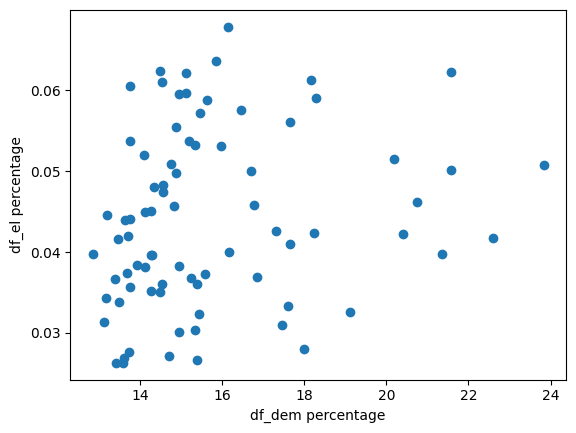

In [23]:
plt.scatter(df_dem['percentage'], df_el['percentage'])
plt.xlabel('df_dem percentage')
plt.ylabel('df_el percentage')
plt.show()

In [24]:
df_el['percentage'].corr(df_dem['percentage'])

np.float64(0.4156326651984162)